In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
from sklearn.model_selection import KFold
import random


d:\shemo_env\shemo_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [3]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Shemo Loading for Whisper

In [4]:
whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_medium')

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
reset_seed(42)
emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}


audios = []
sample_rates = []
emotions = []
labels = []
file_names = []
file_paths = []
features = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))
                file_names.append(filename)
                file_paths.append(file_path)

In [6]:
len(features)

2962

In [7]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)
kf.get_n_splits(features)

5

In [8]:
kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [9]:
for i, (train_index, test_index) in enumerate(kf.split(features)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[   0    1    2 ... 2958 2959 2960]
  Test:  index=[   7   12   29   30   32   43   44   45   51   56   63   67   70   73
   80   87   93   96  102  104  108  111  120  124  134  135  139  141
  144  149  152  162  168  170  173  174  175  177  178  183  184  188
  192  194  196  199  203  210  211  212  218  221  226  231  233  239
  246  251  254  256  257  270  272  282  283  289  291  296  298  309
  313  314  318  321  322  324  331  332  351  354  365  366  367  368
  387  393  402  407  408  410  411  414  415  420  422  423  430  432
  433  436  439  443  450  457  460  463  464  471  478  479  485  486
  495  498  506  507  509  511  521  527  528  532  533  535  543  544
  554  555  557  564  565  567  568  572  581  594  598  599  602  605
  610  612  637  642  644  650  651  670  676  677  678  679  685  693
  695  700  705  727  736  741  742  744  746  748  761  764  765  772
  781  783  785  789  807  809  811  817  819  829  838  839  840  842
  8

In [10]:
(train_index1, test_index1), (train_index2, test_index2),(train_index3, test_index3),(train_index4, test_index4),(train_index5, test_index5) = kf.split(features)

In [11]:
trainF1features = [value for index, value in enumerate(features) if index in train_index1]
trainF2features = [value for index, value in enumerate(features) if index in train_index2]
trainF3features = [value for index, value in enumerate(features) if index in train_index3]
trainF4features = [value for index, value in enumerate(features) if index in train_index4]
trainF5features = [value for index, value in enumerate(features) if index in train_index5]

trainF1labels = [value for index, value in enumerate(labels) if index in train_index1]
trainF2labels = [value for index, value in enumerate(labels) if index in train_index2]
trainF3labels = [value for index, value in enumerate(labels) if index in train_index3]
trainF4labels = [value for index, value in enumerate(labels) if index in train_index4]
trainF5labels = [value for index, value in enumerate(labels) if index in train_index5]

testF1features = [value for index, value in enumerate(features) if index in test_index1]
testF2features = [value for index, value in enumerate(features) if index in test_index2]
testF3features = [value for index, value in enumerate(features) if index in test_index3]
testF4features = [value for index, value in enumerate(features) if index in test_index4]
testF5features = [value for index, value in enumerate(features) if index in test_index5]

testF1labels = [value for index, value in enumerate(labels) if index in test_index1]
testF2labels = [value for index, value in enumerate(labels) if index in test_index2]
testF3labels = [value for index, value in enumerate(labels) if index in test_index3]
testF4labels = [value for index, value in enumerate(labels) if index in test_index4]
testF5labels = [value for index, value in enumerate(labels) if index in test_index5]

In [12]:
class AudioDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]])  # Convert to PyTorch tensor if not already
        }

        return sample


Fold1train = AudioDataSet(trainF1features, trainF1labels)
Fold1test = AudioDataSet(testF1features, testF1labels)

Fold2train = AudioDataSet(trainF2features, trainF2labels)
Fold2test = AudioDataSet(testF2features, testF2labels)

Fold3train = AudioDataSet(trainF3features, trainF3labels)
Fold3test = AudioDataSet(testF3features, testF3labels)

Fold4train = AudioDataSet(trainF4features, trainF4labels)
Fold4test = AudioDataSet(testF4features, testF4labels)

Fold5train = AudioDataSet(trainF5features, trainF5labels)
Fold5test = AudioDataSet(testF5features, testF5labels)



# Example of using DataLoader for batching
train_loaderF1 = DataLoader(Fold1train, batch_size=4, shuffle=True)
val_loaderF1 = DataLoader(Fold1test, batch_size=4, shuffle=False)

train_loaderF2 = DataLoader(Fold2train, batch_size=4, shuffle=True)
val_loaderF2 = DataLoader(Fold2test, batch_size=4, shuffle=False)

train_loaderF3 = DataLoader(Fold3train, batch_size=4, shuffle=True)
val_loaderF3 = DataLoader(Fold3test, batch_size=4, shuffle=False)

train_loaderF4 = DataLoader(Fold4train, batch_size=4, shuffle=True)
val_loaderF4 = DataLoader(Fold4test, batch_size=4, shuffle=False)

train_loaderF5 = DataLoader(Fold5train, batch_size=4, shuffle=True)
val_loaderF5 = DataLoader(Fold5test, batch_size=4, shuffle=False)

In [13]:
loader_lists = [(train_loaderF1, val_loaderF1), (train_loaderF2, val_loaderF2), (train_loaderF3, val_loaderF3), (train_loaderF4, val_loaderF4), (train_loaderF5, val_loaderF5)]

## Train Function for Whisper

In [14]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {num_correct / num_examples : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [15]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    output = model(inputs).logits
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'wonder'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'wonder'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss: .2f} | U_Accuracy: {u_acc : .2f} | W_Accuracy: {w_acc : .2f} | Precision: {precision : .2f} | Recall: {recall : .2f} | f1: {f1 : .2f}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

# Whisper Tiny

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 369.63 seconds, Training Loss:  1.03, Validation Loss: 0.71, Validation Accuracy:  0.74


Epoch: 2 finished in 370.12 seconds, Training Loss:  0.75, Validation Loss: 0.59, Validation Accuracy:  0.78


Epoch: 3 finished in 370.90 seconds, Training Loss:  0.62, Validation Loss: 0.77, Validation Accuracy:  0.76


Epoch: 4 finished in 370.01 seconds, Training Loss:  0.55, Validation Loss: 0.62, Validation Accuracy:  0.79


...

Epoch: 36 finished in 370.14 seconds, Training Loss:  0.25, Validation Loss: 0.46, Validation Accuracy:  0.85


Epoch: 37 finished in 370.11 seconds, Training Loss:  0.25, Validation Loss: 0.64, Validation Accuracy:  0.79


Epoch: 38 finished in 370.16 seconds, Training Loss:  0.27, Validation Loss: 0.48, Validation Accuracy:  0.85


Epoch: 39 finished in 370.26 seconds, Training Loss:  0.25, Validation Loss: 0.51, Validation Accuracy:  0.84


Epoch: 40 finished in 370.18 seconds, Training Loss:  0.28, Validation Loss: 0.49, Validation Accuracy:  0.84
Each epoch took 370.17 seconds in average.


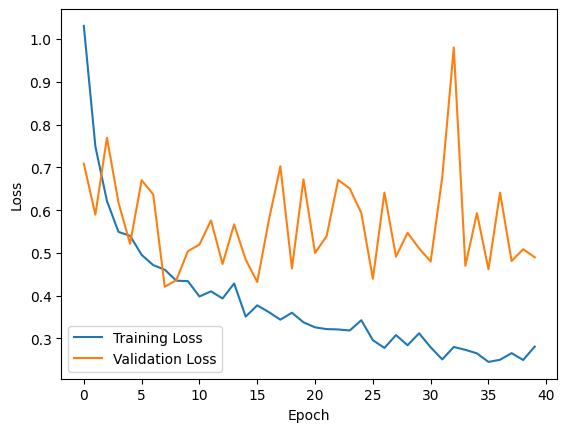

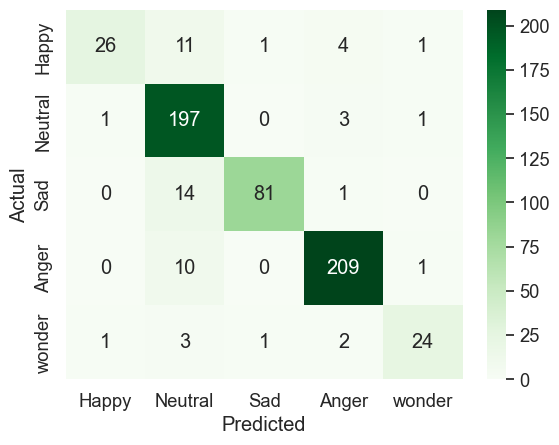

Testing finished with Loss:  0.25 | U_Accuracy:  0.83 | W_Accuracy:  0.91 | Precision:  0.91 | Recall:  0.91 | f1:  0.90
Accuracy per class:
Class 0: 0.6046511627906976
Class 1: 0.9752475247524752
Class 2: 0.84375
Class 3: 0.95
Class 4: 0.7741935483870968


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 371.86 seconds, Training Loss:  0.99, Validation Loss: 0.87, Validation Accuracy:  0.66


Epoch: 2 finished in 371.44 seconds, Training Loss:  0.68, Validation Loss: 0.60, Validation Accuracy:  0.80


Epoch: 3 finished in 371.41 seconds, Training Loss:  0.61, Validation Loss: 0.62, Validation Accuracy:  0.79


...

Epoch: 36 finished in 370.09 seconds, Training Loss:  0.24, Validation Loss: 0.58, Validation Accuracy:  0.83


Epoch: 37 finished in 374.12 seconds, Training Loss:  0.26, Validation Loss: 0.58, Validation Accuracy:  0.82


Epoch: 38 finished in 376.02 seconds, Training Loss:  0.24, Validation Loss: 0.53, Validation Accuracy:  0.82


Epoch: 39 finished in 370.09 seconds, Training Loss:  0.24, Validation Loss: 0.60, Validation Accuracy:  0.81


Epoch: 40 finished in 371.68 seconds, Training Loss:  0.25, Validation Loss: 0.89, Validation Accuracy:  0.78
Each epoch took 370.63 seconds in average.


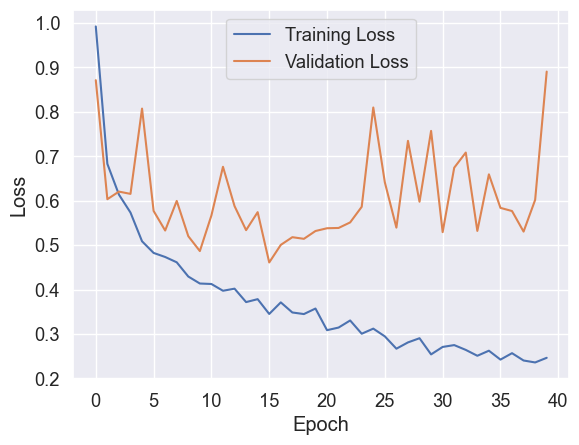

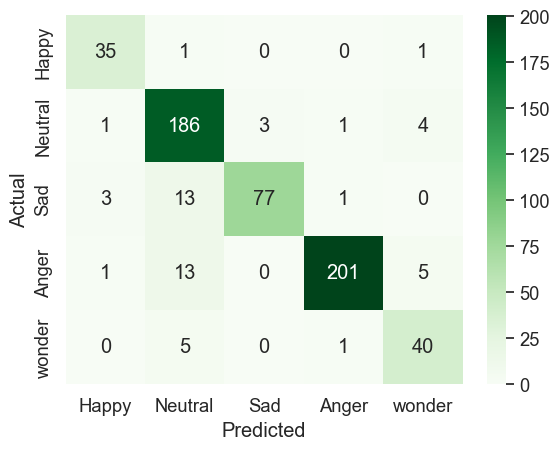

Testing finished with Loss:  0.25 | U_Accuracy:  0.90 | W_Accuracy:  0.91 | Precision:  0.92 | Recall:  0.91 | f1:  0.91
Accuracy per class:
Class 0: 0.9459459459459459
Class 1: 0.9538461538461539
Class 2: 0.8191489361702128
Class 3: 0.9136363636363637
Class 4: 0.8695652173913043


In [16]:
for i, (train_loader, val_loader) in enumerate(loader_lists[3:]):
    whisper_tiny_path = 'whisper_medium'
    whisper_tiny = WhisperForAudioClassification.from_pretrained(
        whisper_tiny_path
    )

    for param in whisper_tiny.parameters():
        param.requires_grad = False

    for param in whisper_tiny.projector.parameters():
        param.requires_grad = True

    whisper_tiny.classifier = torch.nn.Linear(256, 5) # Changing the head to fit our data and problem
    whisper_tiny.to(device)

    optimizer = torch.optim.Adam(whisper_tiny.parameters(), lr=0.001)

    training_losses0, valid_losses0 = train(whisper_tiny, f'whisper_medium_shemo_simple_fold{i +4}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

    plt.plot(training_losses0, label='Training Loss')
    plt.plot(valid_losses0, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    whisper_tiny.load_state_dict(torch.load(f'whisper_medium_shemo_simple_fold{i +1}.bin'))
    test(whisper_tiny, torch.nn.CrossEntropyLoss(), val_loader)

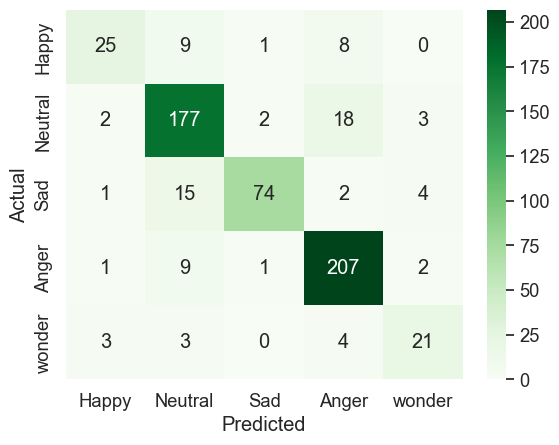

Testing finished with Loss:  0.42 | U_Accuracy:  0.77 | W_Accuracy:  0.85 | Precision:  0.85 | Recall:  0.85 | f1:  0.85
Accuracy per class:
Class 0: 0.5813953488372093
Class 1: 0.8762376237623762
Class 2: 0.7708333333333334
Class 3: 0.9409090909090909
Class 4: 0.6774193548387096


In [18]:
whisper_tiny.load_state_dict(torch.load(f'whisper_medium_shemo_simple_fold{4}.bin'))
test(whisper_tiny, torch.nn.CrossEntropyLoss(), loader_lists[3][1])

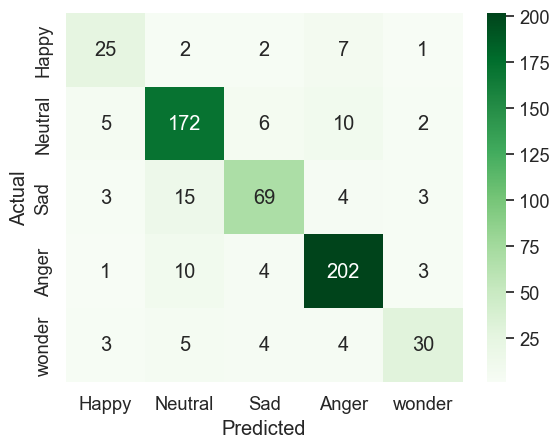

Testing finished with Loss:  0.46 | U_Accuracy:  0.77 | W_Accuracy:  0.84 | Precision:  0.84 | Recall:  0.84 | f1:  0.84
Accuracy per class:
Class 0: 0.6756756756756757
Class 1: 0.882051282051282
Class 2: 0.7340425531914894
Class 3: 0.9181818181818182
Class 4: 0.6521739130434783


In [19]:
whisper_tiny.load_state_dict(torch.load(f'whisper_medium_shemo_simple_fold{5}.bin'))
test(whisper_tiny, torch.nn.CrossEntropyLoss(), loader_lists[4][1])